In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hesh97/titanicdataset-traincsv")


c:\stuff\Code\Python\Machine-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [4]:
data = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
titanic_df = data.loc[:, ["Pclass", "Sex", "Age", "Fare", "Survived"]]
titanic_df = pd.get_dummies(titanic_df, drop_first=True)
titanic_df["Survived"] = titanic_df["Survived"].astype(int)
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace=True)
titanic_df.isna().sum()
titanic_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_14792\3862619262.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].mean(), inplace=True)


,Pclass,Age,Fare,Survived,Sex_male
0,3,22.0,7.2500,0,True
1,1,38.0,71.2833,1,False
2,3,26.0,7.9250,1,False
3,1,35.0,53.1000,1,False
4,3,35.0,8.0500,0,True


In [6]:

X = titanic_df.drop("Survived", axis=1).values
y = titanic_df["Survived"]

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

[0.7653631284916201, 0.8156424581005587, 0.8044692737430168, 0.8100558659217877, 0.8212290502793296, 0.8268156424581006, 0.8100558659217877, 0.8156424581005587, 0.7821229050279329, 0.7932960893854749, 0.770949720670391, 0.7877094972067039, 0.7988826815642458, 0.7932960893854749, 0.7988826815642458, 0.7988826815642458, 0.7877094972067039, 0.7932960893854749, 0.7877094972067039, 0.7932960893854749, 0.8100558659217877, 0.7988826815642458, 0.7932960893854749, 0.7988826815642458, 0.7821229050279329, 0.7988826815642458, 0.7877094972067039, 0.7877094972067039, 0.776536312849162, 0.770949720670391, 0.770949720670391, 0.770949720670391, 0.7821229050279329, 0.776536312849162, 0.7821229050279329, 0.7821229050279329, 0.7877094972067039, 0.7877094972067039, 0.7821229050279329, 0.7821229050279329, 0.7877094972067039, 0.7877094972067039, 0.7821229050279329, 0.8044692737430168, 0.7988826815642458, 0.8044692737430168, 0.7877094972067039, 0.7877094972067039, 0.7821229050279329, 0.7877094972067039, 0.787

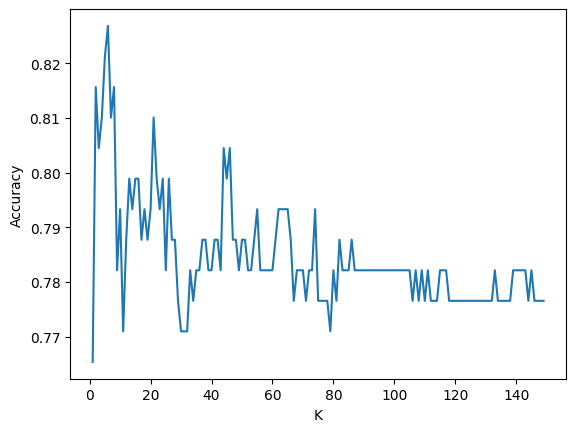

In [10]:
train_accuracy = []
ks = np.arange(1, 150)
for i in ks:
    knn_new = KNeighborsClassifier(n_neighbors=i)
    knn_new.fit(X_train_scaled, y_train)
    y_pred = knn_new.predict(X_test_scaled)
    train_accuracy.append(accuracy_score(y_test, y_pred))
print(train_accuracy)

plt.plot(ks, train_accuracy)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()


# Finding Best Hyperparameter for KNN

In [ ]:
knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": np.arange(1, 21)
}


grid = GridSearchCV(knn, cv=5, param_grid=param_grid, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

print(f"BEST K: {grid.best_params_["n_neighbors"]}, Best Score {grid.best_score_}")

knn_model = grid.best_estimator_

test_acc = knn_model.score(X_test_scaled, y_test)
print("Best Model Score ", test_acc)

y_pred = knn_model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))


BEST K: 3, Best Score 0.8160248202501723
Best Model Score  0.8044692737430168
[[96 14]
 [21 48]]
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [7]:
dt = DecisionTreeClassifier()
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8,9, 10]
}

grid_dt = GridSearchCV(dt, param_grid, scoring="accuracy", cv=10, n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)
print(f"Best ParamsL {grid_dt.best_params_} Best Score {grid_dt.best_score_} Best Estimator {grid_dt.best_estimator_}")

dt_model = grid_dt.best_estimator_
test_acc = dt_model.score(X_test_scaled, y_test)

print("Best Model Score ", test_acc)
y_pred = dt_model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Best ParamsL {'max_depth': 5} Best Score 0.8244522691705789 Best Estimator DecisionTreeClassifier(max_depth=5)
Best Model Score  0.7653631284916201
[[99 11]
 [31 38]]
              precision    recall  f1-score   support

           0       0.76      0.90      0.82       110
           1       0.78      0.55      0.64        69

    accuracy                           0.77       179
   macro avg       0.77      0.73      0.73       179
weighted avg       0.77      0.77      0.76       179

